# Librerías

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import pandas as pd
import re
from urllib.parse import urlsplit, urlunsplit
from tqdm import tqdm 
import sys 
import ast


tqdm.pandas()

In [10]:
sys.path.append('../src/')

In [13]:
from process_results.exists_url import url_exists
from process_results.source_identification import classify_link_peer_review, unknown_breakdown, refine_unknowns_df

/Users/melissa/Projects/GenAI-Science/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Constantes

In [17]:
PATH = '../data/results/'

# Lectura de datos

In [18]:
df_mistral = pd.read_csv(PATH + 'results_mistral.csv')

In [19]:
df_mistral.head()

,prompt,result,references,tokens
0,"I want to write an article about: ""Common fair...",Title: Incompatibility of Common Fairness Defi...,[],NaN
1,"I want to write an article about: ""Machine Lea...","Title: ""Unveiling Bias in Machine Learning: Th...",[],NaN
2,"I want to write an article about: ""Evaluation ...","Title: ""Fairness in Machine Learning: Beyond I...",[],NaN
3,"I want to write an article about: ""Benchmark c...","Title: ""Benchmarking Bias in AI: A Systematic ...",[],NaN
4,"I want to write an article about: ""Word embedd...",Title: Gender Bias in Word Embeddings: A Surve...,[],NaN


# Extract URLs

In [20]:
_URL_RE = re.compile(r'https?://[^\s<>"\']+')

def _clean_url(u: str) -> str:
    """
    Limpia basura común al final: ), ], }, ., ,, ;, :
    y normaliza levemente.
    """
    u = u.strip()

    # Recorta cierres típicos que se pegan en Markdown o puntuación final
    while u and u[-1] in ')]}.,;:':
        u = u[:-1]

    # Opcional: normaliza (sin tocar query/utm)
    # (esto evita cosas raras como espacios u otros, pero es suave)
    parts = urlsplit(u)
    return urlunsplit(parts)

def extract_urls_from_text(text) -> list[str]:
    """
    Devuelve una lista (orden de aparición) con todas las URLs encontradas en el texto.
    Maneja NaN/None.
    """
    if text is None:
        return []
    # Pandas puede traer NaN (float)
    if isinstance(text, float) and pd.isna(text):
        return []

    s = str(text)

    urls = []
    for m in _URL_RE.finditer(s):
        urls.append(_clean_url(m.group(0)))

    # De-duplicar manteniendo orden
    seen = set()
    out = []
    for u in urls:
        if u and u not in seen:
            seen.add(u)
            out.append(u)
    return out

In [21]:
df_mistral["urls_clean"] = df_mistral["result"].apply(extract_urls_from_text)

In [22]:
df_mistral_urls = df_mistral.explode("urls_clean").dropna(subset='urls_clean')

# Existen los URL?

In [23]:
df_mistral_urls["url_check"] = df_mistral_urls["urls_clean"].progress_apply(url_exists)

100%|██████████| 475/475 [11:59<00:00,  1.51s/it]


In [24]:
df_mistral_urls["url_check"].apply(lambda x: x["exists"]).value_counts()

url_check
False    296
True     179
Name: count, dtype: int64

In [25]:
df_mistral_urls_exist = df_mistral_urls[df_mistral_urls["url_check"].apply(lambda x: x["exists"])]

In [26]:
df_mistral_urls_exist['url_check'].iloc[0]

{'url': 'https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing',
 'exists': True,
 'status_code': 200,
 'final_url': 'https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing',
 'error': None}

In [27]:
from src.process_results.classify_urls import classify_url                    

In [28]:
df_mistral_urls_revision = df_mistral_urls_exist[df_mistral_urls_exist.url_check.apply(lambda x: x['exists'])]
df_mistral_urls_revision['clasificacion'] = df_mistral_urls_revision['urls_clean'].progress_apply(
    classify_url)
print(df_mistral_urls_revision.shape)
# Nuevo
df_mistral_urls_revision['clasificacion'].apply(lambda x: x['peer_reviewed']).value_counts()

100%|██████████| 179/179 [00:02<00:00, 72.90it/s]

(179, 7)


clasificacion
no    138
sí     41
Name: count, dtype: int64

In [30]:
df_mistral_urls_revision.to_csv('../data/analisis/processed/mistral_classify.csv', index = None)

# Reference Verification (non-URL citations)

In [33]:
from process_results.reference_verification import (
    extract_references,
    extract_title,
    verify_reference,
    verify_references_df,
)

## Extract references per row

In [35]:
df_mistral["references_extracted"] = df_mistral["result"].apply(extract_references)

# Summary: how many citations found per row
ref_counts = df_mistral["references_extracted"].apply(len)
print(f"Total citations extracted: {ref_counts.sum()}")
print(f"Rows with ≥1 citation: {(ref_counts > 0).sum()} / {len(df_mistral)}")
print(f"Citations per row (mean): {ref_counts.mean():.1f}")

Total citations extracted: 11499
Rows with ≥1 citation: 2135 / 2135
Citations per row (mean): 5.4


In [36]:
# Sample extracted references from first row with citations
first_with_refs = df_mistral[df_mistral["references_extracted"].apply(len) > 0].iloc[0]
print(f"Prompt: {first_with_refs['prompt'][:80]}...\n")
for i, ref in enumerate(first_with_refs["references_extracted"], 1):
    print(f"[{i}] {ref[:120]}")

Prompt: I want to write an article about: "Common fairness definitions are mathematicall...

[1] "Axiomatic Approaches to Fair Division" by Robert Aumann and Shmuel Rubinstein. Econometrica, vol. 50, no. 5, 1982, pp. 
[2] "Fair Division and the Cake Cutting Problem" by Robert Aumann and Moshe Tennenholtz. Games and Economic Behavior, vol. 1
[3] "Proportionality, Equality, and the Core" by Martin J. Osborne and Ariel Rubinstein. Econometrica, vol. 54, no. 3, 1986,
[4] "Envy-Freeness and Equality" by Leonid Hurwicz, Eric Maskin, and Robert Myerson. Econometrica, vol. 57, no. 5, 1989, pp.
[5] "Fair Division and the Shapley Value" by Martin J. Osborne and Ariel Rubinstein. Journal of Economic Theory, vol. 34, no
[6] "Fair Division and the Core" by Robert Aumann and Moshe Tennenholtz. Journal of Economic Theory, vol. 38, no. 1, 1987, p
[7] "Fair Division and the Core: A Survey" by Robert Aumann and Moshe Tennenholtz. Journal of Economic Surveys, vol. 1, no. 


## Run reference verification (CrossRef lookup)

In [ ]:
SAVE_PATH = "../data/analisis/processed/mistral_reference_checks.csv"

df_ref_checks = verify_references_df(
    df_mistral,
    save_path=SAVE_PATH,
    save_every=50,
)
df_ref_checks.head()

## Summary statistics

In [61]:
df_ref_checks = pd.read_csv(SAVE_PATH)
df_ref_checks["top_match"] = df_ref_checks['top_match'].apply(lambda x: 
    ast.literal_eval(x) if not pd.isna(x) else None) 

In [62]:
status_counts = df_ref_checks["status"].value_counts()
status_pct = (status_counts / len(df_ref_checks) * 100).round(1)
summary = pd.DataFrame({"count": status_counts, "pct": status_pct})
print(f"Total citations verified: {len(df_ref_checks)}\n")
print(summary)

Total citations verified: 11499

              count   pct
status                   
review         5586  48.6
hallucinated   3103  27.0
exists         2810  24.4


## Examples by category

In [63]:
def show_examples(status, n=3):
    subset = df_ref_checks[df_ref_checks["status"] == status].head(n)
    print(f"=== {status.upper()} (n={len(df_ref_checks[df_ref_checks['status']==status])}) ===\n")
    for _, row in subset.iterrows():
        print(f"Citation       : {row['citation'][:100]}")
        print(f"Title (Mistral): {row['title_extracted']}")
        print(f"Venue (Mistral): {row['venue_extracted'] or '(not found)'}")
        print(f"Title sim      : {row['title_similarity']}")
        print(f"Venue (CrossRef): {row['venue_crossref'] or '(not found)'}")
        print(f"Venue sim      : {row['venue_similarity']}")
        if row["top_match"]:
            m = row["top_match"]
            print(f"CrossRef title : {m.get('title', '')[:80]} ({m.get('published_year')}) [{m.get('type')}]")
        print()

for s in ["exists", "review", "hallucinated"]:
    print('>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>', s)
    if s in df_ref_checks["status"].values:
        show_examples(s)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> exists
=== EXISTS (n=2810) ===

Citation       : Barocas, S., & Selbst, A. (2016). Big data's hidden biases. Communications of the ACM, 59(10), 80-87
Title (Mistral): Fairness in Machine Learning: A Survey
Venue (Mistral): Communications of the ACM
Title sim      : 1.0
Venue (CrossRef): ACM Computing Surveys
Venue sim      : 0.3913
CrossRef title : Fairness in Machine Learning: A Survey (2024) [journal-article]

Citation       : Chouldechova, A. (2017). The limits of fair machine learning. Proceedings of the National Academy of
Title (Mistral): Fairness in Algorithmic Decision Making: A Survey
Venue (Mistral): Proceedings of the National Academy of Sciences
Title sim      : 0.8864
Venue (CrossRef): Proceedings of the 7th ACM IKDD CoDS and 25th COMAD
Venue sim      : 0.5102
CrossRef title : Fairness in Algorithmic Decision Making (2020) [proceedings-article]

Citation       : Caliskan, Aylin, et al., 2017. "Semantics derived automatically from langua

# Análisis por tópico

In [81]:
df_ref_checks = pd.read_csv(SAVE_PATH)
df_ref_checks["top_match"] = df_ref_checks['top_match'].apply(lambda x: 
    ast.literal_eval(x) if not pd.isna(x) else None) 

In [82]:
prompts_topicos = pd.read_csv('../data/prompts_topic.csv')
prompts_topicos['topic'] = prompts_topicos['topic'].apply(lambda x: x.split('-'))
prompts_topicos = prompts_topicos.explode('topic')
prompts_topicos['topic'] = prompts_topicos['topic'].apply(lambda x: int(x.replace('.0', '')))

In [83]:
df_ref_checks = df_ref_checks.merge(prompts_topicos, on = 'prompt', how = 'left')

In [85]:
topics = pd.read_excel('../data/templates.xlsx', sheet_name='Topics')
topics['general topic'] = topics['general topic'].ffill()

In [86]:
prompts_topicos = prompts_topicos.merge(topics, left_on = 'topic', right_on='ID')

In [87]:
df_ref_checks = df_ref_checks.merge(topics, left_on = 'topic', right_on = 'ID', how = 'left')

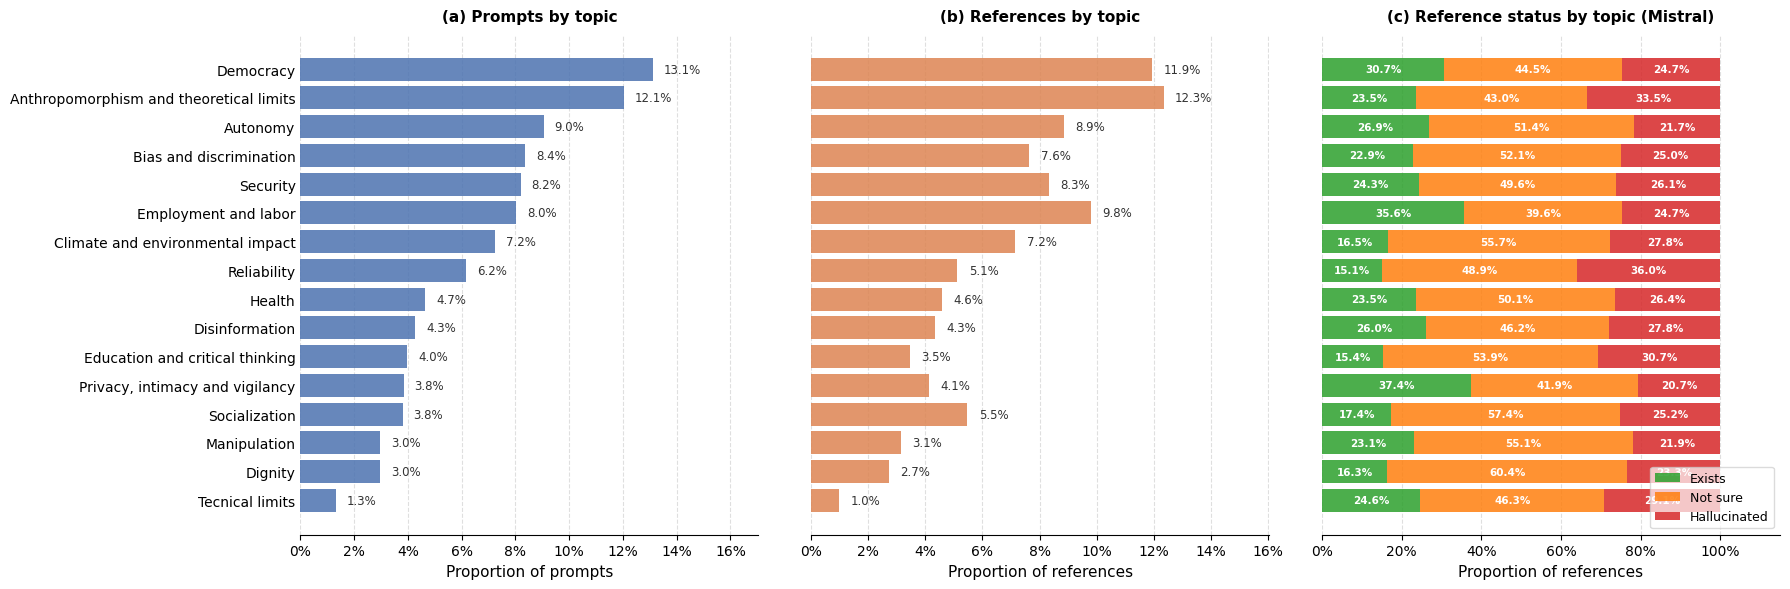

In [98]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Orden de topicos (por proporcion de prompts, ascendente)
topic_order = (
    prompts_topicos
    .drop_duplicates(subset=['prompt', 'general topic'])
    .groupby('general topic')['prompt'].nunique()
    .sort_values().index
)
prop_prompts = (
    prompts_topicos
    .drop_duplicates(subset=['prompt', 'general topic'])
    .groupby('general topic')['prompt'].nunique()
    .reindex(topic_order)
)
prop_prompts = prop_prompts / prop_prompts.sum()

# Merge referencias con topicos
df_topics = df_ref_checks

# (b) Proporcion de referencias por topico
prop_refs = df_topics.groupby('general topic').size().reindex(topic_order).fillna(0)
prop_refs = prop_refs / prop_refs.sum()

# (c) Status breakdown por topico
status_pct = (
    df_topics.groupby(['general topic', 'status']).size()
    .unstack(fill_value=0).reindex(topic_order)
)
status_pct = status_pct.div(status_pct.sum(axis=1), axis=0)
for col in ['exists', 'review', 'hallucinated']:
    if col not in status_pct.columns:
        status_pct[col] = 0.0

STATUS_COLORS = {'exists': '#2ca02c', 'review': '#ff7f0e', 'hallucinated': '#d62728'}
STATUS_LABELS = {'exists': 'Exists', 'review': 'Not sure', 'hallucinated': 'Hallucinated'}

# Figura
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

def style_ax(ax):
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.tick_params(axis='y', length=0)

def add_pct_labels(ax, values):
    for patch, val in zip(ax.patches, values):
        ax.text(patch.get_width() + 0.004, patch.get_y() + patch.get_height() / 2,
                f'{val:.1%}', va='center', ha='left', fontsize=8.5, color='#333333')

# (a) Prompts
ax1.barh(range(len(topic_order)), prop_prompts.values, color='#4C72B0', alpha=0.85, zorder=3)
ax1.set_yticks(range(len(topic_order)))
ax1.set_yticklabels(topic_order, fontsize=10)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax1.set_xlabel('Proportion of prompts', fontsize=11)
ax1.set_title('(a) Prompts by topic', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlim(0, prop_prompts.max() * 1.30)
style_ax(ax1)
add_pct_labels(ax1, prop_prompts.values)

# (b) Referencias
ax2.barh(range(len(topic_order)), prop_refs.values, color='#DD8452', alpha=0.85, zorder=3)
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.set_xlabel('Proportion of references', fontsize=11)
ax2.set_title('(b) References by topic', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlim(0, prop_refs.max() * 1.30)
style_ax(ax2)
add_pct_labels(ax2, prop_refs.values)

# (c) Status stacked
left = [0.0] * len(topic_order)
for status in ['exists', 'review', 'hallucinated']:
    vals = status_pct[status].fillna(0).values
    bars = ax3.barh(range(len(topic_order)), vals, left=left,
                    color=STATUS_COLORS[status], alpha=0.85,
label=STATUS_LABELS[status], zorder=3)
    # Etiqueta en el centro de cada segmento
    for i, (patch, val) in enumerate(zip(bars.patches, vals)):
        if val > 0.04:  # solo si el segmento es suficientemente ancho
            cx = patch.get_x() + patch.get_width() / 2
            cy = patch.get_y() + patch.get_height() / 2
            ax3.text(cx, cy, f'{val:.1%}', va='center', ha='center',
                    fontsize=7.5, color='white', fontweight='bold')
    left = [l + v for l, v in zip(left, vals)]

ax3.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax3.set_xlabel('Proportion of references', fontsize=11)
ax3.set_title('(c) Reference status by topic (Mistral)', fontsize=11, fontweight='bold', pad=10)
ax3.set_xlim(0, 1.15)
ax3.legend(loc='lower right', framealpha=0.7, fontsize=9)
style_ax(ax3)

plt.tight_layout(w_pad=2)
#plt.savefig('data/analisis/topic_distribution_mistral.pdf', bbox_inches='tight', dpi=300)
plt.show()

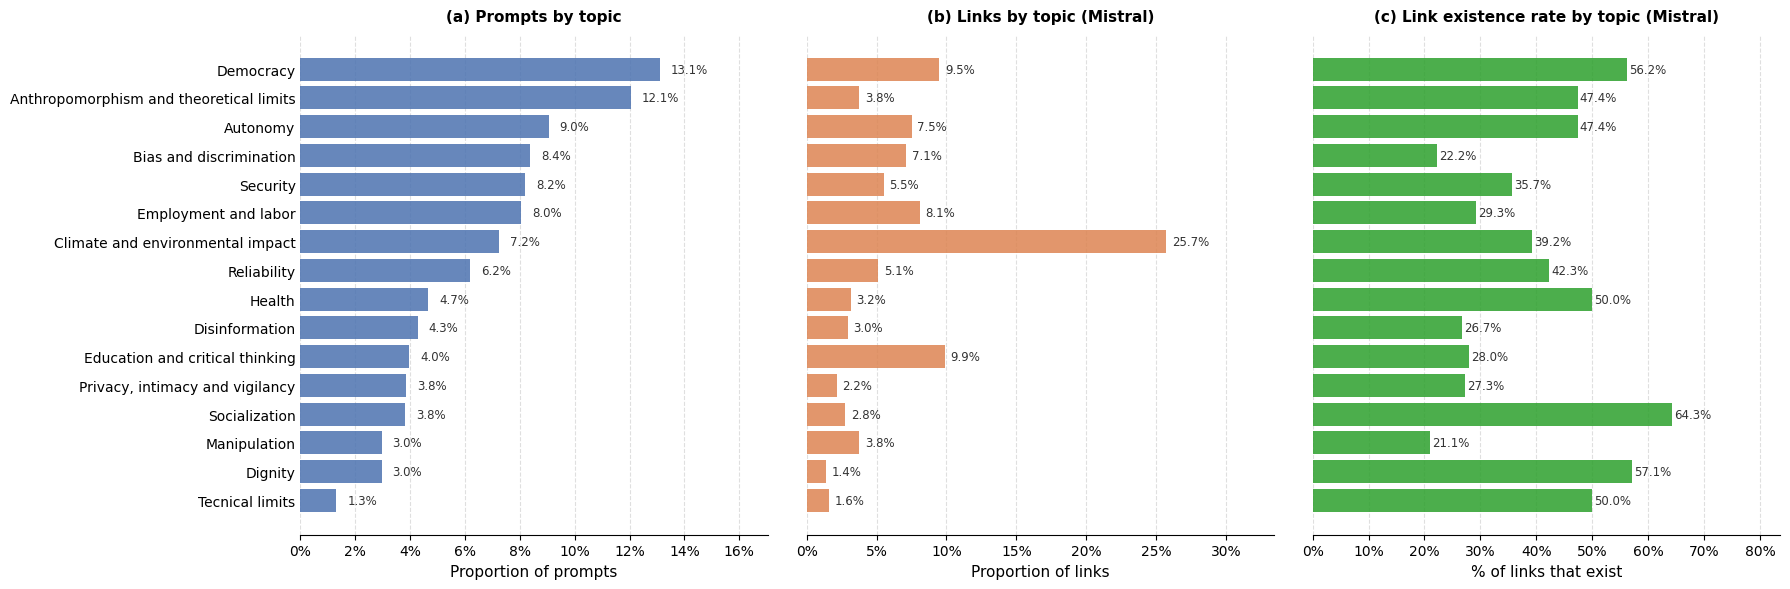

In [103]:
import matplotlib.pyplot as plt                                            
import matplotlib.ticker as mtick
                                                                            
# Orden de topicos
topic_order = (                                                            
    prompts_topicos
    .drop_duplicates(subset=['prompt', 'general topic'])                   
    .groupby('general topic')['prompt'].nunique()                          
    .sort_values().index                                                   
)                                                                          
prop_prompts = (                                                           
    prompts_topicos                            
    .drop_duplicates(subset=['prompt', 'general topic'])                   
    .groupby('general topic')['prompt'].nunique()                          
    .reindex(topic_order)                                                  
)                                                                          
prop_prompts = prop_prompts / prop_prompts.sum()                           
                                                
# Merge df_mistral_urls con topicos                                        
prompt_topic_map = prompts_topicos[['prompt', 'general topic']].drop_duplicates()                                                 
df_urls_topics = df_mistral_urls.merge(prompt_topic_map, on='prompt',
how='left')                                                                
df_urls_topics['exists'] = df_urls_topics['url_check'].apply(lambda x:
x['exists'])                   
                                                
# (b) Proporcion de links por topico
prop_links = df_urls_topics.groupby('general topic').size().reindex(topic_order).fillna(0)                              
prop_links = prop_links / prop_links.sum()
                                                                            
# (c) % de links que existen por topico
exist_rate = (                                                             
    df_urls_topics.groupby('general topic')['exists']
    .apply(lambda x: x.sum() / len(x))                                     
    .reindex(topic_order).fillna(0)            
)                                                                          
                
# Figura                                                                   
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)    
                                                                            
def style_ax(ax):                                                          
    for spine in ['top', 'right', 'left']:                                 
        ax.spines[spine].set_visible(False)                                
    ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    ax.tick_params(axis='y', length=0)                                     
                                                                            
def add_pct_labels(ax, values):                                            
    for patch, val in zip(ax.patches, values):                             
        ax.text(patch.get_width() + 0.004, patch.get_y() +                 
patch.get_height() / 2,                                                    
                f'{val:.1%}', va='center', ha='left', fontsize=8.5,        
color='#333333')                                                           
                                
# (a) Prompts                                                              
ax1.barh(range(len(topic_order)), prop_prompts.values, color='#4C72B0',
alpha=0.85, zorder=3)                                                      
ax1.set_yticks(range(len(topic_order)))        
ax1.set_yticklabels(topic_order, fontsize=10)                              
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))  
ax1.set_xlabel('Proportion of prompts', fontsize=11)                       
ax1.set_title('(a) Prompts by topic', fontsize=11, fontweight='bold',      
pad=10)                                                                    
ax1.set_xlim(0, prop_prompts.max() * 1.30)                                 
style_ax(ax1)                                                              
add_pct_labels(ax1, prop_prompts.values)       
                                                                            
# (b) Links por topico                                                     
ax2.barh(range(len(topic_order)), prop_links.values, color='#DD8452',
alpha=0.85, zorder=3)                                                      
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.set_xlabel('Proportion of links', fontsize=11)                         
ax2.set_title('(b) Links by topic (Mistral)', fontsize=11, fontweight='bold', pad=10)
ax2.set_xlim(0, prop_links.max() * 1.30)                                   
style_ax(ax2)   
add_pct_labels(ax2, prop_links.values)                                     
                                                
# (c) % links que existen                                                  
ax3.barh(range(len(topic_order)), exist_rate.values, color='#2ca02c',
alpha=0.85, zorder=3)                                                      
ax3.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax3.set_xlabel('% of links that exist', fontsize=11)                       
ax3.set_title('(c) Link existence rate by topic (Mistral)', fontsize=11,
fontweight='bold', pad=10)                                                 
ax3.set_xlim(0, exist_rate.max() * 1.30)       
style_ax(ax3)                                                              
add_pct_labels(ax3, exist_rate.values)         
                                                                            
plt.tight_layout(w_pad=2)                      
#plt.savefig('data/analisis/topic_links_mistral.pdf', bbox_inches='tight',  dpi=300)                                                                   
plt.show()  